# Optimización Bayesiana

|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 26/3/2026  |
| **Expediente** |757839   |

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

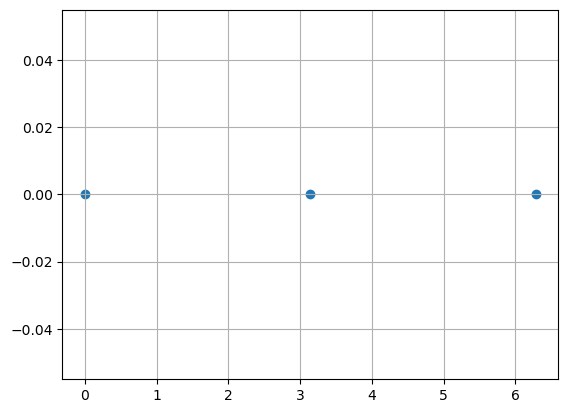

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

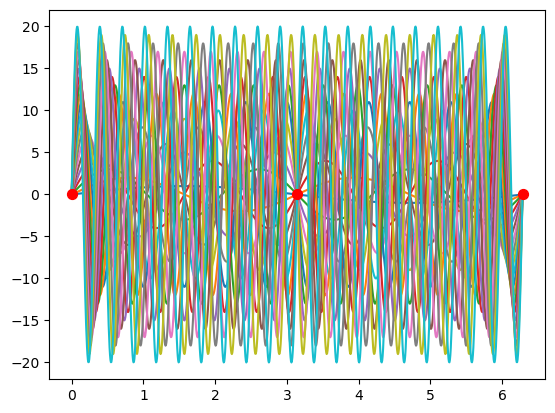

In [17]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

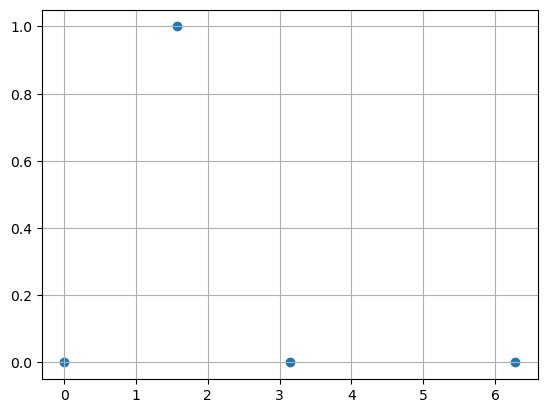

In [18]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

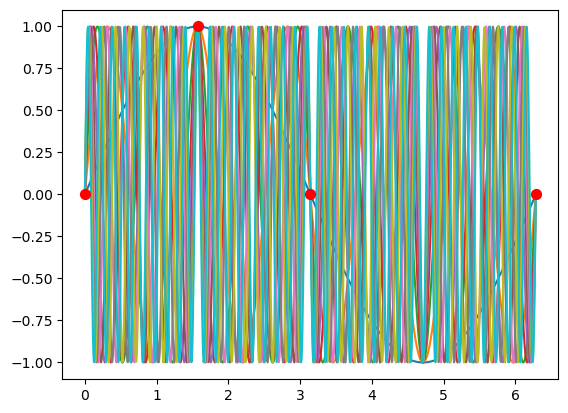

In [29]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

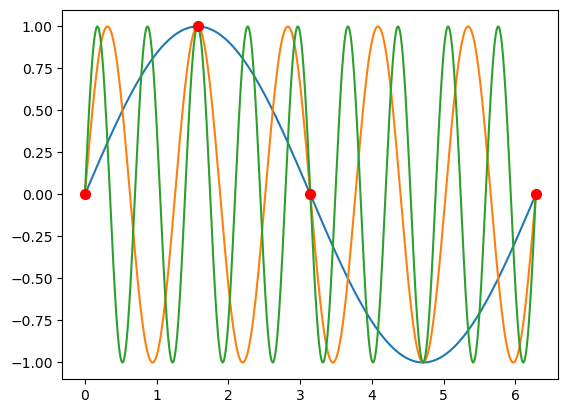

In [30]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

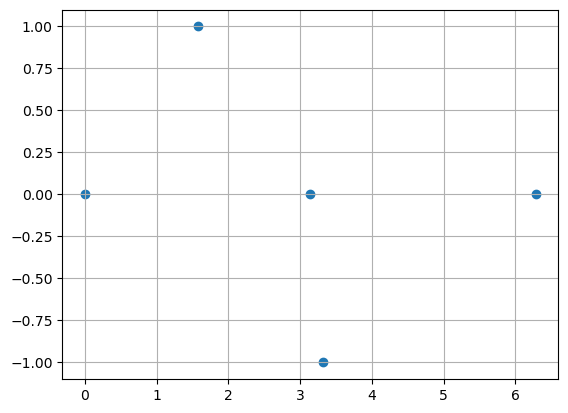

In [59]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

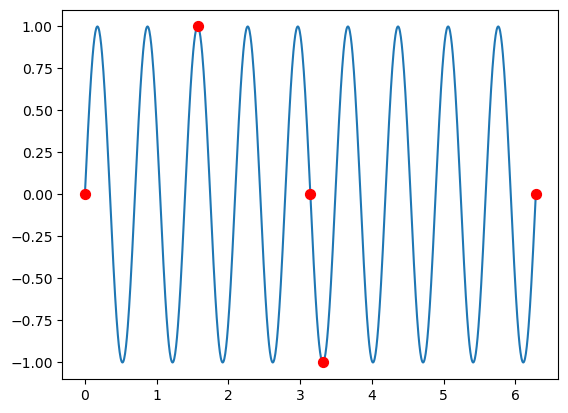

In [172]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

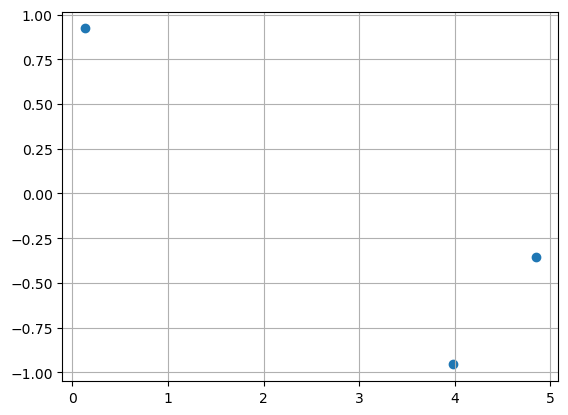

In [183]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor

# Función objetivo
def f(x):
    return np.sin(x/3) + np.cos(2*x)

# Muestras iniciales
X_sample = np.array([[-12], [2], [10]])
y_sample = f(X_sample)

# Rango de visualización
x_range = np.linspace(-5 * np.pi, 5 * np.pi, 1000).reshape(-1, 1)

In [8]:
# Regresión simple sin especificar kernels manuales
gp = GaussianProcessRegressor(n_restarts_optimizer=10)
gp.fit(X_sample, y_sample)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",None
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

In [9]:
# Predicción de media y desviación estándar
mu, sigma = gp.predict(x_range, return_std=True)

Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cw/f9fpy1lx3733m7j4914dyl_m0000gn/T/ipykernel_10879/1453297075.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x_range, mu, color='royalblue', linewidth=2.5, label='Predicción Media $\mu(x)$')


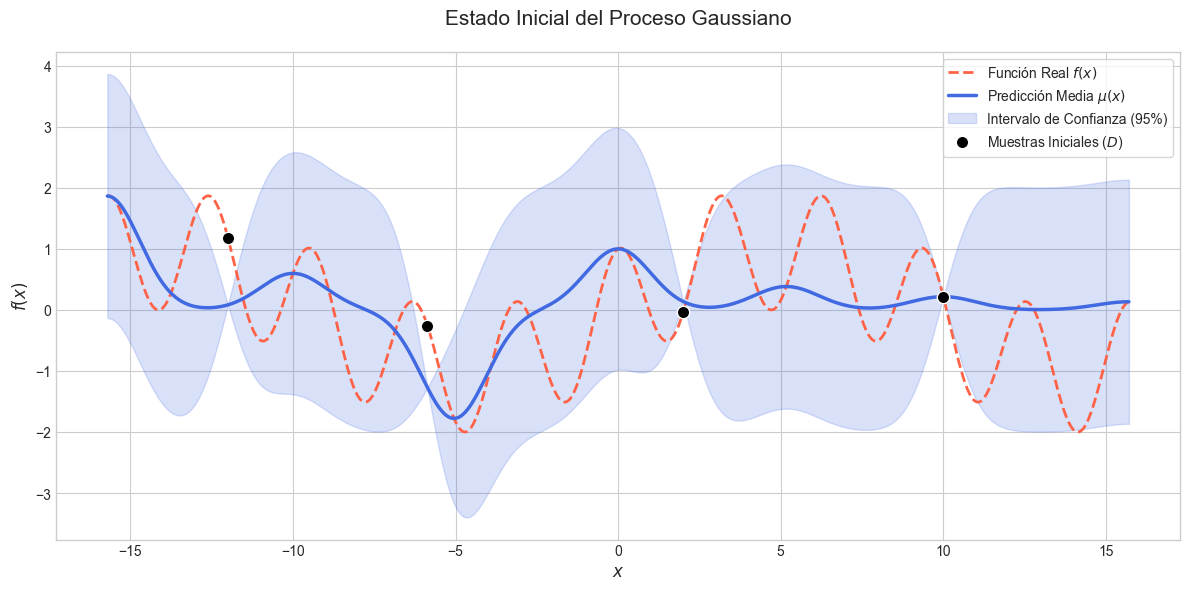

In [16]:
# Configuración estética de la gráfica
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo más limpio

# Graficar la función real (objetivo)
plt.plot(x_range, f(x_range), color='tomato', linestyle='--', linewidth=2, label='Función Real $f(x)$')

# Graficar la predicción del modelo (Media)
plt.plot(x_range, mu, color='royalblue', linewidth=2.5, label='Predicción Media $\mu(x)$')

# Graficar el intervalo de confianza (Incertidumbre de 2 desviaciones estándar)
plt.fill_between(
    x_range.flatten(), 
    (mu - 2 * sigma).flatten(), 
    (mu + 2 * sigma).flatten(), 
    color='royalblue', 
    alpha=0.2, 
    label='Intervalo de Confianza (95%)'
)

# Graficar las muestras iniciales tomadas
plt.scatter(X_sample, y_sample, color='black', s=80, zorder=5, label='Muestras Iniciales ($D$)', edgecolor='white')

# Títulos y etiquetas
plt.title('Estado Inicial del Proceso Gaussiano', fontsize=15, pad=20)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)
- Minimizar (busco mi predicción del mínimo actual y pido esa medida)
- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

In [11]:
# Identificamos los puntos sugeridos por cada criterio
x_max_pred = x_range[np.argmax(mu)]
x_min_pred = x_range[np.argmin(mu)]
x_max_sigma = x_range[np.argmax(sigma)]

print(f"Sugerencia Max: {x_max_pred}, Min: {x_min_pred}, Incertidumbre: {x_max_sigma}")

Sugerencia Max: [-11.99717315], Min: [1.99690824], Incertidumbre: [-5.86493523]


Y repetimos el proceso ya con nueva información.

In [12]:
# Añadimos el punto de mayor incertidumbre
x_new = x_max_sigma
y_new = f(x_new)

X_sample = np.vstack((X_sample, x_new))
y_sample = np.vstack((y_sample, y_new))

# Volvemos a ajustar y predecir
gp.fit(X_sample, y_sample)
mu, sigma = gp.predict(x_range, return_std=True)

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

In [13]:
# Preparación para el ciclo de 30 iteraciones
X_step = np.array([[-10], [0], [10]])
y_step = f(X_step)

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.

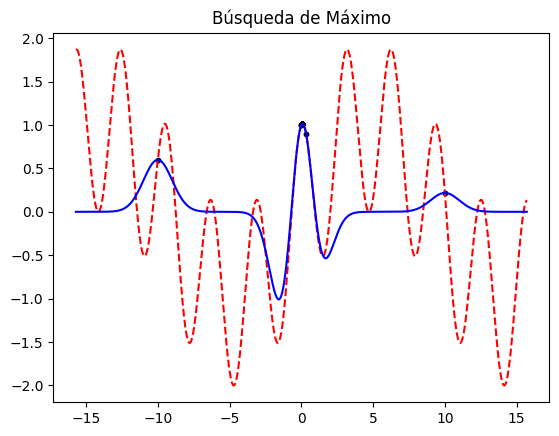

In [14]:
for i in range(30):
    gp.fit(X_step, y_step)
    mu, _ = gp.predict(x_range, return_std=True)
    
    # Elegimos el máximo
    idx_next = np.argmax(mu)
    x_next = x_range[idx_next]
    
    X_step = np.vstack((X_step, x_next))
    y_step = np.vstack((y_step, f(x_next)))

# Gráfica final Máximo
plt.plot(x_range, f(x_range), 'r--')
plt.plot(x_range, mu, 'b-')
plt.scatter(X_step, y_step, c='black', s=10)
plt.title("Búsqueda de Máximo")
plt.show()

2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.

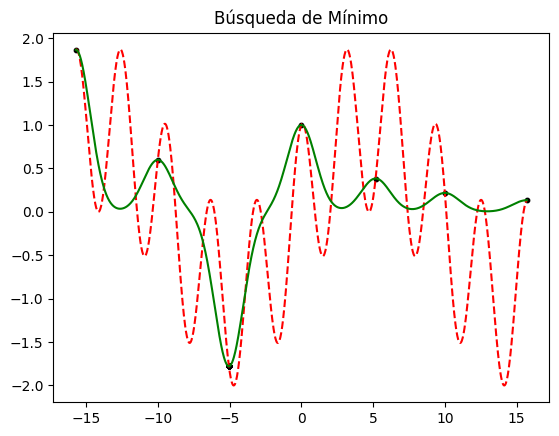

In [15]:
# Reiniciamos datos para el mínimo
X_step_min = np.array([[-10], [0], [10]])
y_step_min = f(X_step_min)

for i in range(30):
    gp.fit(X_step_min, y_step_min)
    mu, _ = gp.predict(x_range, return_std=True)
    
    # Elegimos el mínimo
    idx_next = np.argmin(mu)
    x_next = x_range[idx_next]
    
    X_step_min = np.vstack((X_step_min, x_next))
    y_step_min = np.vstack((y_step_min, f(x_next)))

# Gráfica final Mínimo
plt.plot(x_range, f(x_range), 'r--')
plt.plot(x_range, mu, 'g-')
plt.scatter(X_step_min, y_step_min, c='black', s=10)
plt.title("Búsqueda de Mínimo")
plt.show()

Se ve que la optimización bayesiana es útil en estos casos donde hay espacios no convexos donde hay irregularidades donde un espacio convexo normalmente es más simple, al hacer procesos gaussianos el modelo aprende una muy ruta general del posible camino donde podría haver una ruta uena de manera muy general y la optimización bayesiana da la combinación de parametros para seguir la ruta del proceso gaussiano que da la mayor precisión en el modelo. Al ser eficiente al modelar valores esperados así como la incertidumbre logra dar un buen balance entre explorar "rutas" y aprovechar la mejor, siendo muy útil en este tipo de espacios complejos (No convexos).